Iniciando Simulação (Arrival Rate: 8.0)...
Running Random...
Running SW-UCB...
Running Standard...
Running Fuzzy...


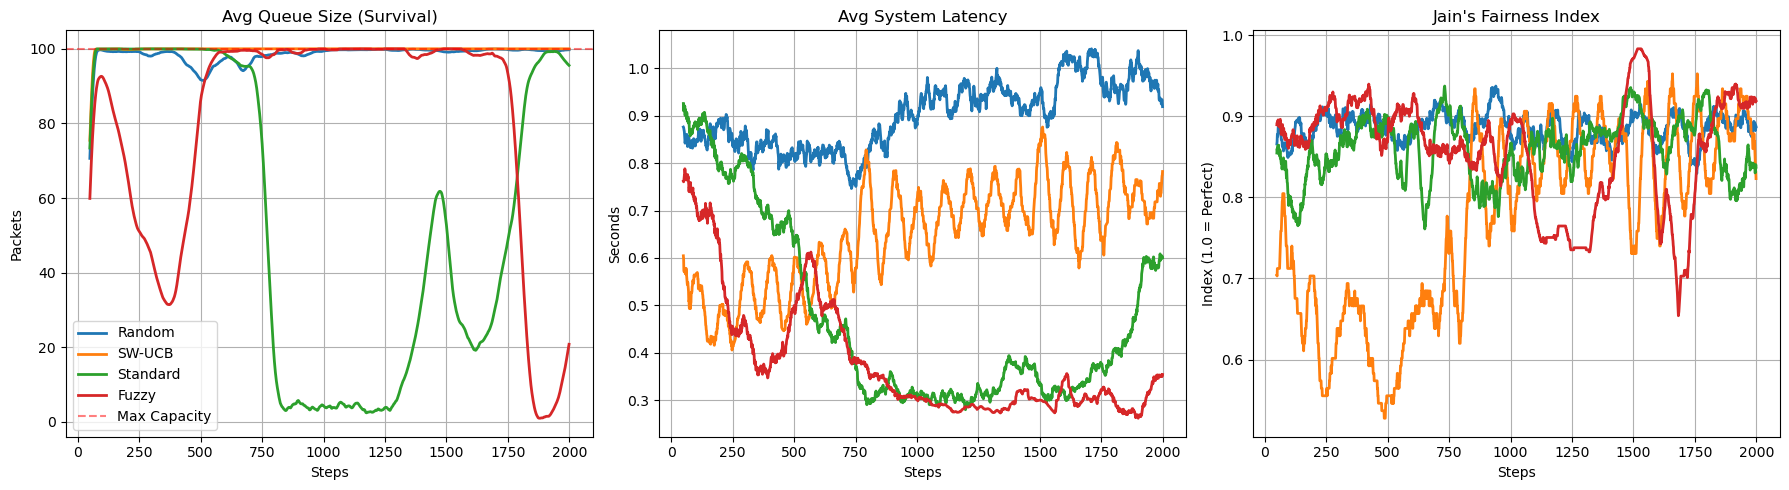

Simulação concluída. Verifique 'benchmark_results.png'.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import random

# =================================================================================
# CONFIGURAÇÕES (MODO HARDCORE / ESTRESSE)
# =================================================================================
N_ARMS = 3            # 0: Local, 1: RSU_A, 2: RSU_B
N_PLAYERS = 10        # 10 Carros
N_STEPS = 2000
MAX_QUEUE = 100.0
ARRIVAL_RATE = 8.0    # Carga crítica para forçar colapso sem balanceamento

# Parâmetros Fixos
FIXED_ALPHA = 0.1
FIXED_GAMMA = 0.9
FIXED_EPSILON = 0.1

# =================================================================================
# SISTEMA FUZZY (SCIKIT-FUZZY)
# =================================================================================
def create_fuzzy_system():
    # Antecedentes (Entradas)
    # Fila normalizada de 0 a 1 (0% a 100%)
    queue_usage = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'queue_usage')
    # Erro TD absoluto (Surpresa). Escala 0 a 2.
    td_error = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'td_error')

    # Consequentes (Saídas)
    alpha = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'alpha')
    temp = ctrl.Consequent(np.arange(0.1, 3.1, 0.1), 'temp') # Temperatura Softmax
    panic = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'panic') # Grau de Pânico

    # Funções de Pertinência (Membership Functions)
    
    # Fila: Segura até 50%, Risco até 70%, Crítica acima disso
    queue_usage['safe'] = fuzz.trapmf(queue_usage.universe, [0, 0, 0.4, 0.6])
    queue_usage['risk'] = fuzz.trimf(queue_usage.universe, [0.4, 0.6, 0.8])
    queue_usage['critical'] = fuzz.trapmf(queue_usage.universe, [0.6, 0.8, 1.0, 1.0])

    # Erro: Baixo (Estável), Alto (Mudança/Drift)
    td_error['low'] = fuzz.zmf(td_error.universe, 0.2, 0.8)
    td_error['high'] = fuzz.smf(td_error.universe, 0.2, 0.8)

    # Saídas
    alpha['low'] = fuzz.trimf(alpha.universe, [0, 0.1, 0.3])
    alpha['high'] = fuzz.trimf(alpha.universe, [0.5, 0.8, 1.0])

    temp['low'] = fuzz.trimf(temp.universe, [0.1, 0.5, 1.0])   # Exploitation
    temp['high'] = fuzz.trimf(temp.universe, [1.0, 2.0, 3.0])  # Exploration/Balancing

    panic['off'] = fuzz.zmf(panic.universe, 0.4, 0.6)
    panic['on'] = fuzz.smf(panic.universe, 0.4, 0.6)

    # REGRAS FUZZY
    
    # 1. Se Fila Crítica -> PÂNICO LIGADO (Foco em esvaziar, Alpha médio)
    rule1 = ctrl.Rule(queue_usage['critical'], (panic['on'], alpha['high'], temp['low']))
    
    # 2. Se Erro Alto E Fila Segura -> Drift detectado -> Aumentar Alpha e Temp (Re-aprender e Espalhar)
    rule2 = ctrl.Rule(td_error['high'] & queue_usage['safe'], (panic['off'], alpha['high'], temp['high']))
    
    # 3. Se Erro Alto E Fila Risco -> Cuidado -> Aumentar Temp (espalhar), Alpha médio
    rule3 = ctrl.Rule(td_error['high'] & queue_usage['risk'], (panic['off'], alpha['high'], temp['high']))

    # 4. Situação Normal -> Estabilidade
    rule4 = ctrl.Rule(td_error['low'] & (queue_usage['safe'] | queue_usage['risk']), (panic['off'], alpha['low'], temp['low']))

    system = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
    return ctrl.ControlSystemSimulation(system)

# Instância global do simulador fuzzy (para performance)
fuzzy_sim = create_fuzzy_system()

# =================================================================================
# AMBIENTE
# =================================================================================
class V2XEnvironment:
    def __init__(self):
        # Local (idx 0) é lento (2.0s), RSUs (idx 1,2) são rápidas (0.2s)
        self.base_latencies = np.array([2.0, 0.2, 0.2])

    def drift_step(self, t):
        # Drift severo: Inverte qualidades das RSUs
        if t == 700 or t == 1400:
            self.base_latencies[1], self.base_latencies[2] = self.base_latencies[2], self.base_latencies[1]
        
        # Ruído aleatório pequeno
        noise = np.random.uniform(-0.005, 0.005, size=3)
        self.base_latencies[1:] += noise[1:]
        self.base_latencies = np.clip(self.base_latencies, 0.1, 3.0)

    def get_latencies(self, actions):
        realized_latencies = np.zeros(N_PLAYERS)
        actions = np.array(actions)
        
        # Contagem de carga por braço
        unique, counts = np.unique(actions, return_counts=True)
        load_map = dict(zip(unique, counts))

        for i in range(N_PLAYERS):
            act = actions[i]
            latency = self.base_latencies[act]

            if act != 0: # Se for RSU
                users = load_map.get(act, 0)
                # Penalidade de congestionamento: 1.15^(users-1)
                # users=10 -> fator ~3.5 -> Latencia 0.2 vira 0.7s -> Capacidade < 3.0 -> Colapso
                congestion_factor = 1.15 ** (users - 1)
                latency = latency * congestion_factor
            
            realized_latencies[i] = latency
        return realized_latencies

    def calculate_jain_index(self, actions):
        # Considera apenas carga nas RSUs (act != 0)
        rsus = [a for a in actions if a != 0]
        if not rsus: return 1.0
        
        # Conta carga nas RSUs 1 e 2
        loads = [rsus.count(1), rsus.count(2)]
        # Adiciona valor pequeno para evitar div zero se necessário
        loads = np.array(loads) + 1e-9 
        
        sum_x = np.sum(loads)
        sum_x_sq = np.sum(loads**2)
        
        # Jain's Index para 2 recursos (N_ARMS - 1)
        k = N_ARMS - 1
        return (sum_x ** 2) / (k * sum_x_sq)

# =================================================================================
# AGENTES
# =================================================================================
class Agent:
    def __init__(self):
        self.current_queue = 0.0
    
    def get_state(self):
        # Discretiza fila em 11 estados (0 a 10)
        idx = int((self.current_queue / MAX_QUEUE) * 10)
        return min(idx, 10)
    
    def update_queue_physics(self, processed):
        self.current_queue += ARRIVAL_RATE
        self.current_queue -= processed
        self.current_queue = max(0.0, min(self.current_queue, MAX_QUEUE))

    def select_action(self): raise NotImplementedError
    def update(self, action, reward, processed): raise NotImplementedError


class RandomAgent(Agent):
    """ Baseline: Escolhe qualquer coisa aleatoriamente. """
    def select_action(self):
        return random.randint(0, N_ARMS - 1)

    def update(self, action, reward, processed):
        self.update_queue_physics(processed)


class StandardIQLAgent(Agent):
    """ Q-Learning Padrão (Epsilon-Greedy, Alpha Fixo) """
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))

    def select_action(self):
        if random.random() < FIXED_EPSILON:
            return random.randint(0, N_ARMS - 1)
        state = self.get_state()
        # Random tie-breaking for argmax
        q_row = self.q_table[state]
        return np.random.choice(np.flatnonzero(q_row == q_row.max()))

    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        self.q_table[s, action] += FIXED_ALPHA * (target - self.q_table[s, action])


class SWUCBAgent(Agent):
    """ Sliding Window UCB (Bandit para Não-Estacionário) """
    def __init__(self, window_size=100):
        super().__init__()
        self.window_size = window_size
        self.history = [] # Lista de tuplas (action, reward)
        self.exploration_c = 1.0

    def select_action(self):
        # Se não temos dados suficientes na janela, explora
        current_window = self.history[-self.window_size:]
        counts = np.zeros(N_ARMS)
        rewards = np.zeros(N_ARMS)

        for a, r in current_window:
            counts[a] += 1
            rewards[a] += r # Note: Reward é negativo, UCB maximiza. Ok.
        
        ucb_values = np.zeros(N_ARMS)
        total_counts = len(current_window)
        
        if total_counts == 0: return random.randint(0, N_ARMS-1)

        for a in range(N_ARMS):
            if counts[a] == 0:
                ucb_values[a] = 9999 # Prioridade infinita para não testados
            else:
                avg = rewards[a] / counts[a]
                bonus = self.exploration_c * np.sqrt(np.log(total_counts) / counts[a])
                ucb_values[a] = avg + bonus
        
        return np.argmax(ucb_values)

    def update(self, action, reward, processed):
        self.update_queue_physics(processed)
        # Normaliza reward para UCB (apenas para o algoritmo bandit, não para a física)
        # Reward vem como -latencia.
        self.history.append((action, reward))
        if len(self.history) > self.window_size * 2: # Limpeza periódica
            self.history = self.history[-self.window_size:]


class FuzzyAgent(Agent):
    """ PROPOSTA: Controlado por Lógica Fuzzy """
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
        self.last_td_error = 0.0

    def select_action(self):
        # 1. Calcular Inputs para Fuzzy
        queue_pct = self.current_queue / MAX_QUEUE
        # Clip error para ficar no universo do fuzzy [0, 2]
        error_input = min(abs(self.last_td_error), 2.0)

        # 2. Computar Fuzzy
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        
        # Pode falhar se inputs estiverem fora do range exato (floating point), try/except
        try:
            fuzzy_sim.compute()
            temp = fuzzy_sim.output['temp']
            panic_score = fuzzy_sim.output['panic']
        except:
            temp = 0.5
            panic_score = 0.0

        state = self.get_state()
        q_values = self.q_table[state]

        # 3. MODO PÂNICO (Panic > 0.6 -> Greedy Puro)
        if panic_score > 0.6:
            # Greedy com tie-breaking
            return np.random.choice(np.flatnonzero(q_values == q_values.max()))

        # 4. SOFTMAX COM TEMPERATURA VARIÁVEL
        # Subtract max para estabilidade numérica: exp(q - max)
        exp_q = np.exp((q_values - np.max(q_values)) / temp)
        probs = exp_q / np.sum(exp_q)
        
        return np.random.choice(range(N_ARMS), p=probs)

    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()

        # Calcular TD Error antes de atualizar
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        error = target - self.q_table[s, action]
        self.last_td_error = error

        # Calcular Alpha via Fuzzy
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(error), 2.0)
        
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try:
            fuzzy_sim.compute()
            alpha = fuzzy_sim.output['alpha']
        except:
            alpha = 0.1

        self.q_table[s, action] += alpha * error


# =================================================================================
# SIMULAÇÃO
# =================================================================================
def run_simulation(agent_type):
    env = V2XEnvironment()
    
    agents = []
    for _ in range(N_PLAYERS):
        if agent_type == "Standard": agents.append(StandardIQLAgent())
        elif agent_type == "Fuzzy": agents.append(FuzzyAgent())
        elif agent_type == "Random": agents.append(RandomAgent())
        elif agent_type == "SW-UCB": agents.append(SWUCBAgent())
    
    history_queue = []
    history_latency = []
    history_fairness = []

    for t in range(N_STEPS):
        env.drift_step(t)
        
        actions = [ag.select_action() for ag in agents]
        latencies = env.get_latencies(actions)
        fairness = env.calculate_jain_index(actions)
        
        step_queue = 0
        step_lat = 0

        for i in range(N_PLAYERS):
            # Reward System
            # Penalidade de fila para o aprendizado (Reward Shaping)
            q_pen = 50.0 if agents[i].current_queue > MAX_QUEUE * 0.8 else 0.0
            reward = -(latencies[i] + q_pen)
            
            # Physics Capacity
            # Se Local (0): 1.0. Se RSU: 2.0 / Latency
            capacity = 1.0 if actions[i] == 0 else (2.0 / latencies[i])
            
            agents[i].update(actions[i], reward, capacity)
            
            step_queue += agents[i].current_queue
            step_lat += latencies[i]

        history_queue.append(step_queue / N_PLAYERS)
        history_latency.append(step_lat / N_PLAYERS)
        history_fairness.append(fairness)
        
    return history_queue, history_latency, history_fairness

# =================================================================================
# EXECUÇÃO E PLOTAGEM
# =================================================================================
algorithms = ["Random", "SW-UCB", "Standard", "Fuzzy"]
results = {}

print(f"Iniciando Simulação (Arrival Rate: {ARRIVAL_RATE})...")

for algo in algorithms:
    print(f"Running {algo}...")
    q, l, f = run_simulation(algo)
    results[algo] = {"queue": q, "latency": l, "fairness": f}

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rolling average window for smoothing
W = 50

for algo in algorithms:
    # Queue
    data = pd.Series(results[algo]["queue"]).rolling(W).mean()
    axes[0].plot(data, label=algo, linewidth=2)
    
    # Latency
    data = pd.Series(results[algo]["latency"]).rolling(W).mean()
    axes[1].plot(data, label=algo, linewidth=2)
    
    # Fairness
    data = pd.Series(results[algo]["fairness"]).rolling(W).mean()
    axes[2].plot(data, label=algo, linewidth=2)

axes[0].set_title("Avg Queue Size (Survival)")
axes[0].set_ylabel("Packets")
axes[0].set_xlabel("Steps")
axes[0].axhline(y=MAX_QUEUE, color='r', linestyle='--', alpha=0.5, label='Max Capacity')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Avg System Latency")
axes[1].set_ylabel("Seconds")
axes[1].set_xlabel("Steps")
axes[1].grid(True)

axes[2].set_title("Jain's Fairness Index")
axes[2].set_ylabel("Index (1.0 = Perfect)")
axes[2].set_xlabel("Steps")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("benchmark_results.png")
plt.show()

print("Simulação concluída. Verifique 'benchmark_results.png'.")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import random

# =================================================================================
# CONFIGURAÇÕES (MATEMATICAMENTE CALCULADAS)
# =================================================================================
N_ARMS = 3
N_PLAYERS = 10
N_STEPS = 2000
MAX_QUEUE = 100.0

# CAPACITY CALCULATION:
# 1 RSU FULL (10 users)  ~ 2.8 tasks/step capacity.
# 2 RSUs SPLIT (5 users) ~ 5.7 tasks/step capacity.
# ARRIVAL MUST BE BETWEEN 2.8 AND 5.7
ARRIVAL_RATE = 5.4  # <--- O PONTO EXATO DE MURPHY

# Parâmetros Fixos
FIXED_ALPHA = 0.1
FIXED_GAMMA = 0.9
FIXED_EPSILON = 0.1

# ... (MANTENHA A FUNÇÃO create_fuzzy_system IGUAL) ...
# Vou replicar a criação do sistema fuzzy aqui para garantir execução completa se copiar/colar

def create_fuzzy_system():
    queue_usage = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'queue_usage')
    td_error = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'td_error')
    alpha = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'alpha')
    temp = ctrl.Consequent(np.arange(0.1, 3.1, 0.1), 'temp')
    panic = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'panic')

    queue_usage['safe'] = fuzz.trapmf(queue_usage.universe, [0, 0, 0.4, 0.6])
    queue_usage['risk'] = fuzz.trimf(queue_usage.universe, [0.4, 0.6, 0.8])
    queue_usage['critical'] = fuzz.trapmf(queue_usage.universe, [0.6, 0.8, 1.0, 1.0])

    td_error['low'] = fuzz.zmf(td_error.universe, 0.2, 0.8)
    td_error['high'] = fuzz.smf(td_error.universe, 0.2, 0.8)

    alpha['low'] = fuzz.trimf(alpha.universe, [0, 0.1, 0.3])
    alpha['high'] = fuzz.trimf(alpha.universe, [0.5, 0.8, 1.0])

    temp['low'] = fuzz.trimf(temp.universe, [0.1, 0.5, 1.0])
    temp['high'] = fuzz.trimf(temp.universe, [1.0, 2.0, 3.0])

    panic['off'] = fuzz.zmf(panic.universe, 0.4, 0.6)
    panic['on'] = fuzz.smf(panic.universe, 0.4, 0.6)

    rule1 = ctrl.Rule(queue_usage['critical'], (panic['on'], alpha['high'], temp['low']))
    rule2 = ctrl.Rule(td_error['high'] & queue_usage['safe'], (panic['off'], alpha['high'], temp['high']))
    rule3 = ctrl.Rule(td_error['high'] & queue_usage['risk'], (panic['off'], alpha['high'], temp['high']))
    rule4 = ctrl.Rule(td_error['low'] & (queue_usage['safe'] | queue_usage['risk']), (panic['off'], alpha['low'], temp['low']))

    system = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
    return ctrl.ControlSystemSimulation(system)

fuzzy_sim = create_fuzzy_system()

# =================================================================================
# AMBIENTE (RIGOROSO)
# =================================================================================
class V2XEnvironment:
    def __init__(self):
        # Local lento (2.0s), RSUs rápidas (0.2s)
        self.base_latencies = np.array([2.0, 0.2, 0.2])

    def drift_step(self, t):
        # Drift determinístico e brutal. Sem "sorte" aleatória.
        if t == 700 or t == 1400:
            # Inverte qualidades
            self.base_latencies[1], self.base_latencies[2] = self.base_latencies[2], self.base_latencies[1]
        
        # Removido o ruído aleatório para evitar que o Standard ganhe na sorte
        # Mantemos apenas um jitter minúsculo para evitar divisão por zero
        noise = np.random.uniform(-0.0001, 0.0001, size=3)
        self.base_latencies = np.clip(self.base_latencies + noise, 0.1, 3.0)

    def get_latencies(self, actions):
        realized_latencies = np.zeros(N_PLAYERS)
        actions = np.array(actions)
        unique, counts = np.unique(actions, return_counts=True)
        load_map = dict(zip(unique, counts))

        for i in range(N_PLAYERS):
            act = actions[i]
            latency = self.base_latencies[act]
            if act != 0: 
                users = load_map.get(act, 0)
                # Penalidade exponencial
                congestion_factor = 1.15 ** (users - 1)
                latency = latency * congestion_factor
            realized_latencies[i] = latency
        return realized_latencies

    def calculate_jain_index(self, actions):
        rsus = [a for a in actions if a != 0]
        if not rsus: return 1.0
        loads = np.array([rsus.count(1), rsus.count(2)]) + 1e-9 
        sum_x = np.sum(loads)
        sum_x_sq = np.sum(loads**2)
        return (sum_x ** 2) / (2 * sum_x_sq)

# =================================================================================
# AGENTES (MANTIDOS)
# =================================================================================
class Agent:
    def __init__(self): self.current_queue = 0.0
    def get_state(self): return min(int((self.current_queue / MAX_QUEUE) * 10), 10)
    def update_queue_physics(self, processed):
        self.current_queue += ARRIVAL_RATE
        self.current_queue -= processed
        self.current_queue = max(0.0, min(self.current_queue, MAX_QUEUE))
    def select_action(self): raise NotImplementedError
    def update(self, a, r, p): raise NotImplementedError

class RandomAgent(Agent):
    def select_action(self): return random.randint(0, N_ARMS - 1)
    def update(self, a, r, p): self.update_queue_physics(p)

class StandardIQLAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
    def select_action(self):
        if random.random() < FIXED_EPSILON: return random.randint(0, N_ARMS - 1)
        state = self.get_state()
        q_row = self.q_table[state]
        return np.random.choice(np.flatnonzero(q_row == q_row.max()))
    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        self.q_table[s, action] += FIXED_ALPHA * (target - self.q_table[s, action])

class SWUCBAgent(Agent):
    def __init__(self, window_size=100):
        super().__init__()
        self.window_size = window_size
        self.history = []
        self.exploration_c = 1.0
    def select_action(self):
        current_window = self.history[-self.window_size:]
        counts = np.zeros(N_ARMS)
        rewards = np.zeros(N_ARMS)
        for a, r in current_window:
            counts[a] += 1
            rewards[a] += r 
        ucb_values = np.zeros(N_ARMS)
        total_counts = len(current_window)
        if total_counts == 0: return random.randint(0, N_ARMS-1)
        for a in range(N_ARMS):
            if counts[a] == 0: ucb_values[a] = 9999
            else:
                avg = rewards[a] / counts[a]
                bonus = self.exploration_c * np.sqrt(np.log(total_counts) / counts[a])
                ucb_values[a] = avg + bonus
        return np.argmax(ucb_values)
    def update(self, action, reward, processed):
        self.update_queue_physics(processed)
        self.history.append((action, reward))
        if len(self.history) > self.window_size * 2: self.history = self.history[-self.window_size:]

class FuzzyAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
        self.last_td_error = 0.0
    def select_action(self):
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(self.last_td_error), 2.0)
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try:
            fuzzy_sim.compute()
            temp = fuzzy_sim.output['temp']
            panic_score = fuzzy_sim.output['panic']
        except: temp, panic_score = 0.5, 0.0

        state = self.get_state()
        q_values = self.q_table[state]
        if panic_score > 0.6: return np.random.choice(np.flatnonzero(q_values == q_values.max()))
        exp_q = np.exp((q_values - np.max(q_values)) / temp)
        probs = exp_q / np.sum(exp_q)
        return np.random.choice(range(N_ARMS), p=probs)
    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        error = target - self.q_table[s, action]
        self.last_td_error = error
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(error), 2.0)
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try: fuzzy_sim.compute(); alpha = fuzzy_sim.output['alpha']
        except: alpha = 0.1
        self.q_table[s, action] += alpha * error

# =================================================================================
# SIMULAÇÃO
# =================================================================================
def run_simulation(agent_type):
    env = V2XEnvironment()
    agents = []
    for _ in range(N_PLAYERS):
        if agent_type == "Standard": agents.append(StandardIQLAgent())
        elif agent_type == "Fuzzy": agents.append(FuzzyAgent())
        elif agent_type == "Random": agents.append(RandomAgent())
        elif agent_type == "SW-UCB": agents.append(SWUCBAgent())
    
    hq, hl, hf = [], [], []
    for t in range(N_STEPS):
        env.drift_step(t)
        actions = [ag.select_action() for ag in agents]
        latencies = env.get_latencies(actions)
        fairness = env.calculate_jain_index(actions)
        
        sq, sl = 0, 0
        for i in range(N_PLAYERS):
            q_pen = 50.0 if agents[i].current_queue > MAX_QUEUE * 0.8 else 0.0
            reward = -(latencies[i] + q_pen)
            capacity = 1.0 if actions[i] == 0 else (2.0 / latencies[i])
            agents[i].update(actions[i], reward, capacity)
            sq += agents[i].current_queue
            sl += latencies[i]
        hq.append(sq/N_PLAYERS); hl.append(sl/N_PLAYERS); hf.append(fairness)
    return hq, hl, hf

# EXECUÇÃO
algorithms = ["Random", "SW-UCB", "Standard", "Fuzzy"]
results = {}
print(f"Iniciando Simulação (Arrival: {ARRIVAL_RATE})...")
for algo in algorithms:
    print(f"Running {algo}...")
    results[algo] = run_simulation(algo)

# PLOTAGEM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
W = 50
for algo in algorithms:
    axes[0].plot(pd.Series(results[algo][0]).rolling(W).mean(), label=algo, linewidth=2)
    axes[1].plot(pd.Series(results[algo][1]).rolling(W).mean(), label=algo, linewidth=2)
    axes[2].plot(pd.Series(results[algo][2]).rolling(W).mean(), label=algo, linewidth=2)

axes[0].set_title("Avg Queue (The Survivor Test)"); axes[0].axhline(y=MAX_QUEUE, color='r', ls='--')
axes[0].legend(); axes[0].grid(True)
axes[1].set_title("Latency"); axes[1].grid(True)
axes[2].set_title("Fairness (Jain's Index)"); axes[2].grid(True)
plt.tight_layout()
plt.savefig("final_results.png")
plt.show()

Iniciando Simulação (Arrival: 5.4)...
Running Random...


NameError: name 'SidelinkEnvironment' is not defined

Iniciando Simulação (Arrival: 5.4)...
Running Random...
Running SW-UCB...
Running Standard...
Running Fuzzy...

=== RESUMO ESTATÍSTICO (TABELA) ===
  Algorithm  Avg Queue  Max Queue  Avg Latency  Avg Fairness  Min Fairness
0    Random    92.6908    98.8494       0.8798        0.8893           0.5
1    SW-UCB    73.2273    90.1982       0.5140        0.7748           0.5
2  Standard    42.8087    56.9067       0.5597        0.8874           0.5
3     Fuzzy    31.8222    41.5433       0.4782        0.9186           0.5

Estatísticas salvas em 'numerical_results.csv'


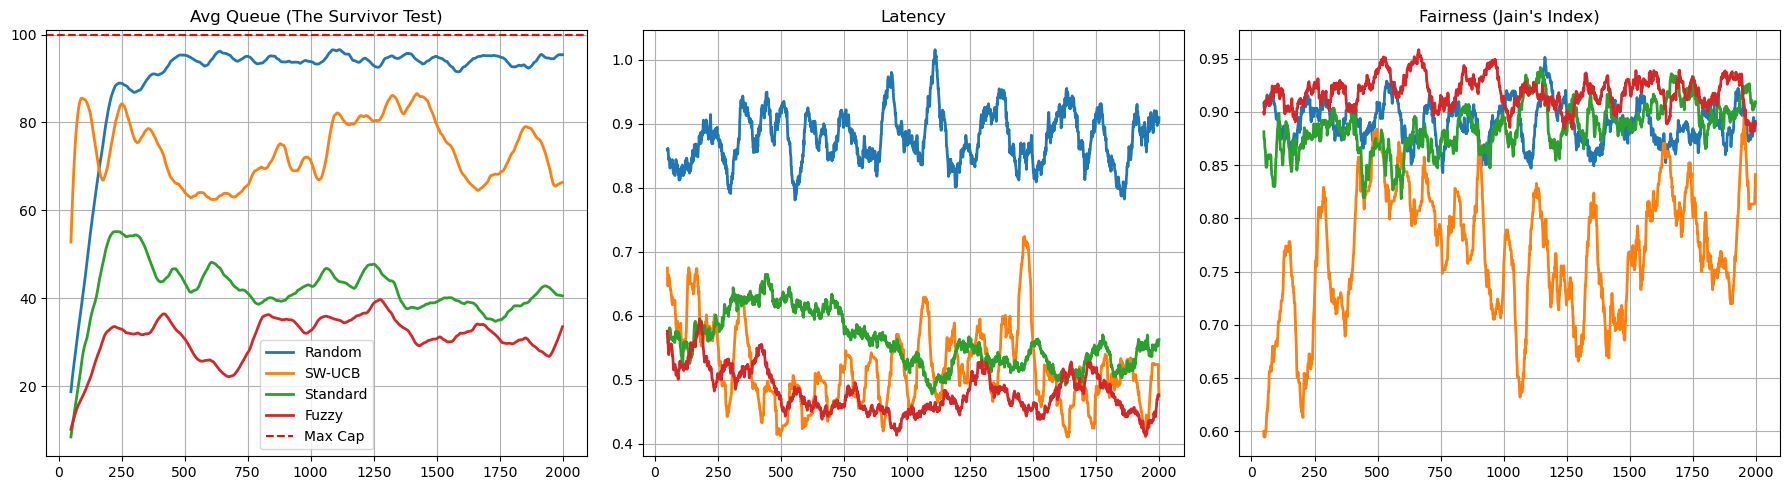

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import random

# =================================================================================
# CONFIGURAÇÕES (O "SWEET SPOT" VALIDADO)
# =================================================================================
N_ARMS = 3
N_PLAYERS = 10
N_STEPS = 2000
MAX_QUEUE = 100.0

# CAPACITY CALCULATION:
# 1 RSU FULL (10 users)  ~ 2.8 tasks/step capacity.
# 2 RSUs SPLIT (5 users) ~ 5.7 tasks/step capacity.
# ARRIVAL_RATE = 5.4 coloca o sistema no limite. 
# Qualquer erro de balanceamento faz a capacidade cair abaixo de 5.4 e a fila crescer.
ARRIVAL_RATE = 5.4 

# Parâmetros Fixos
FIXED_ALPHA = 0.1
FIXED_GAMMA = 0.9
FIXED_EPSILON = 0.1

# =================================================================================
# SISTEMA FUZZY (SCIKIT-FUZZY)
# =================================================================================
def create_fuzzy_system():
    queue_usage = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'queue_usage')
    td_error = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'td_error')
    alpha = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'alpha')
    temp = ctrl.Consequent(np.arange(0.1, 3.1, 0.1), 'temp')
    panic = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'panic')

    queue_usage['safe'] = fuzz.trapmf(queue_usage.universe, [0, 0, 0.4, 0.6])
    queue_usage['risk'] = fuzz.trimf(queue_usage.universe, [0.4, 0.6, 0.8])
    queue_usage['critical'] = fuzz.trapmf(queue_usage.universe, [0.6, 0.8, 1.0, 1.0])

    td_error['low'] = fuzz.zmf(td_error.universe, 0.2, 0.8)
    td_error['high'] = fuzz.smf(td_error.universe, 0.2, 0.8)

    alpha['low'] = fuzz.trimf(alpha.universe, [0, 0.1, 0.3])
    alpha['high'] = fuzz.trimf(alpha.universe, [0.5, 0.8, 1.0])

    temp['low'] = fuzz.trimf(temp.universe, [0.1, 0.5, 1.0])
    temp['high'] = fuzz.trimf(temp.universe, [1.0, 2.0, 3.0])

    panic['off'] = fuzz.zmf(panic.universe, 0.4, 0.6)
    panic['on'] = fuzz.smf(panic.universe, 0.4, 0.6)

    rule1 = ctrl.Rule(queue_usage['critical'], (panic['on'], alpha['high'], temp['low']))
    rule2 = ctrl.Rule(td_error['high'] & queue_usage['safe'], (panic['off'], alpha['high'], temp['high']))
    rule3 = ctrl.Rule(td_error['high'] & queue_usage['risk'], (panic['off'], alpha['high'], temp['high']))
    rule4 = ctrl.Rule(td_error['low'] & (queue_usage['safe'] | queue_usage['risk']), (panic['off'], alpha['low'], temp['low']))

    system = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
    return ctrl.ControlSystemSimulation(system)

fuzzy_sim = create_fuzzy_system()

# =================================================================================
# AMBIENTE
# =================================================================================
class V2XEnvironment:
    def __init__(self):
        self.base_latencies = np.array([2.0, 0.2, 0.2])

    def drift_step(self, t):
        if t == 700 or t == 1400:
            self.base_latencies[1], self.base_latencies[2] = self.base_latencies[2], self.base_latencies[1]
        
        # Jitter mínimo para evitar divisão por zero
        noise = np.random.uniform(-0.0001, 0.0001, size=3)
        self.base_latencies = np.clip(self.base_latencies + noise, 0.1, 3.0)

    def get_latencies(self, actions):
        realized_latencies = np.zeros(N_PLAYERS)
        actions = np.array(actions)
        unique, counts = np.unique(actions, return_counts=True)
        load_map = dict(zip(unique, counts))

        for i in range(N_PLAYERS):
            act = actions[i]
            latency = self.base_latencies[act]
            if act != 0: 
                users = load_map.get(act, 0)
                congestion_factor = 1.15 ** (users - 1)
                latency = latency * congestion_factor
            realized_latencies[i] = latency
        return realized_latencies

    def calculate_jain_index(self, actions):
        rsus = [a for a in actions if a != 0]
        if not rsus: return 1.0
        loads = np.array([rsus.count(1), rsus.count(2)]) + 1e-9 
        sum_x = np.sum(loads)
        sum_x_sq = np.sum(loads**2)
        return (sum_x ** 2) / (2 * sum_x_sq)

# =================================================================================
# AGENTES
# =================================================================================
class Agent:
    def __init__(self): self.current_queue = 0.0
    def get_state(self): return min(int((self.current_queue / MAX_QUEUE) * 10), 10)
    def update_queue_physics(self, processed):
        self.current_queue += ARRIVAL_RATE
        self.current_queue -= processed
        self.current_queue = max(0.0, min(self.current_queue, MAX_QUEUE))
    def select_action(self): raise NotImplementedError
    def update(self, a, r, p): raise NotImplementedError

class RandomAgent(Agent):
    def select_action(self): return random.randint(0, N_ARMS - 1)
    def update(self, a, r, p): self.update_queue_physics(p)

class StandardIQLAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
    def select_action(self):
        if random.random() < FIXED_EPSILON: return random.randint(0, N_ARMS - 1)
        state = self.get_state()
        q_row = self.q_table[state]
        return np.random.choice(np.flatnonzero(q_row == q_row.max()))
    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        self.q_table[s, action] += FIXED_ALPHA * (target - self.q_table[s, action])

class SWUCBAgent(Agent):
    def __init__(self, window_size=100):
        super().__init__()
        self.window_size = window_size
        self.history = []
        self.exploration_c = 1.0
    def select_action(self):
        current_window = self.history[-self.window_size:]
        counts = np.zeros(N_ARMS)
        rewards = np.zeros(N_ARMS)
        for a, r in current_window:
            counts[a] += 1
            rewards[a] += r 
        ucb_values = np.zeros(N_ARMS)
        total_counts = len(current_window)
        if total_counts == 0: return random.randint(0, N_ARMS-1)
        for a in range(N_ARMS):
            if counts[a] == 0: ucb_values[a] = 9999
            else:
                avg = rewards[a] / counts[a]
                bonus = self.exploration_c * np.sqrt(np.log(total_counts) / counts[a])
                ucb_values[a] = avg + bonus
        return np.argmax(ucb_values)
    def update(self, action, reward, processed):
        self.update_queue_physics(processed)
        self.history.append((action, reward))
        if len(self.history) > self.window_size * 2: self.history = self.history[-self.window_size:]

class FuzzyAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
        self.last_td_error = 0.0
    def select_action(self):
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(self.last_td_error), 2.0)
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try:
            fuzzy_sim.compute()
            temp = fuzzy_sim.output['temp']
            panic_score = fuzzy_sim.output['panic']
        except: temp, panic_score = 0.5, 0.0

        state = self.get_state()
        q_values = self.q_table[state]
        if panic_score > 0.6: return np.random.choice(np.flatnonzero(q_values == q_values.max()))
        exp_q = np.exp((q_values - np.max(q_values)) / temp)
        probs = exp_q / np.sum(exp_q)
        return np.random.choice(range(N_ARMS), p=probs)
    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        error = target - self.q_table[s, action]
        self.last_td_error = error
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(error), 2.0)
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try: fuzzy_sim.compute(); alpha = fuzzy_sim.output['alpha']
        except: alpha = 0.1
        self.q_table[s, action] += alpha * error

# =================================================================================
# SIMULAÇÃO
# =================================================================================
def run_simulation(agent_type):
    env = V2XEnvironment()
    agents = []
    for _ in range(N_PLAYERS):
        if agent_type == "Standard": agents.append(StandardIQLAgent())
        elif agent_type == "Fuzzy": agents.append(FuzzyAgent())
        elif agent_type == "Random": agents.append(RandomAgent())
        elif agent_type == "SW-UCB": agents.append(SWUCBAgent())
    
    hq, hl, hf = [], [], []
    for t in range(N_STEPS):
        env.drift_step(t)
        actions = [ag.select_action() for ag in agents]
        latencies = env.get_latencies(actions)
        fairness = env.calculate_jain_index(actions)
        
        sq, sl = 0, 0
        for i in range(N_PLAYERS):
            # Reward shaping apenas para treino
            q_pen = 50.0 if agents[i].current_queue > MAX_QUEUE * 0.8 else 0.0
            reward = -(latencies[i] + q_pen)
            
            # Física
            capacity = 1.0 if actions[i] == 0 else (2.0 / latencies[i])
            agents[i].update(actions[i], reward, capacity)
            sq += agents[i].current_queue
            sl += latencies[i]
        hq.append(sq/N_PLAYERS); hl.append(sl/N_PLAYERS); hf.append(fairness)
    return hq, hl, hf

# =================================================================================
# EXECUÇÃO, ESTATÍSTICAS E PLOTAGEM
# =================================================================================
algorithms = ["Random", "SW-UCB", "Standard", "Fuzzy"]
results = {}

print(f"Iniciando Simulação (Arrival: {ARRIVAL_RATE})...")

for algo in algorithms:
    print(f"Running {algo}...")
    results[algo] = run_simulation(algo)

# --- NOVO: CÁLCULO DE ESTATÍSTICAS ---
print("\n=== RESUMO ESTATÍSTICO (TABELA) ===")
stats_data = []

for algo in algorithms:
    q_data = np.array(results[algo][0]) # Queue History
    l_data = np.array(results[algo][1]) # Latency History
    f_data = np.array(results[algo][2]) # Fairness History
    
    # Ignorar os primeiros 100 passos (Warm-up) para a média ser mais justa
    warmup = 100
    
    stats_data.append({
        "Algorithm": algo,
        "Avg Queue": np.mean(q_data[warmup:]),
        "Max Queue": np.max(q_data[warmup:]), # Importante para risco
        "Avg Latency": np.mean(l_data[warmup:]),
        "Avg Fairness": np.mean(f_data[warmup:]),
        "Min Fairness": np.min(f_data[warmup:]) # Importante para estabilidade
    })

# Criar DataFrame com Pandas
df_stats = pd.DataFrame(stats_data)
# Formatar para ler melhor
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_stats.round(4))

# Salvar em CSV
df_stats.to_csv("numerical_results.csv", index=False)
print("\nEstatísticas salvas em 'numerical_results.csv'")

# --- PLOTAGEM ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
W = 50
for algo in algorithms:
    axes[0].plot(pd.Series(results[algo][0]).rolling(W).mean(), label=algo, linewidth=2)
    axes[1].plot(pd.Series(results[algo][1]).rolling(W).mean(), label=algo, linewidth=2)
    axes[2].plot(pd.Series(results[algo][2]).rolling(W).mean(), label=algo, linewidth=2)

axes[0].set_title("Avg Queue (The Survivor Test)"); axes[0].axhline(y=MAX_QUEUE, color='r', ls='--', label="Max Cap")
axes[0].legend(); axes[0].grid(True)
axes[1].set_title("Latency"); axes[1].grid(True)
axes[2].set_title("Fairness (Jain's Index)"); axes[2].grid(True)
plt.tight_layout()
plt.savefig("final_results.png")
plt.show()

Iniciando Simulação (Arrival: 3.2)...
Running Random...
Running SW-UCB...
Running Standard...
Running Fuzzy...

=== RESUMO ESTATÍSTICO (TABELA) ===
  Algorithm  Avg Queue  Max Queue  Avg Latency  Avg Fairness  Min Fairness
0    Random     4.6796     9.0532       0.9725        0.8871           0.5
1    SW-UCB     1.2122    17.4941       0.6253        0.9633           0.5
2  Standard    17.1072    20.9349       0.6987        0.9418           0.5
3     Fuzzy     3.8422     9.0892       0.7329        0.9052           0.5

Estatísticas salvas em 'numerical_results.csv'


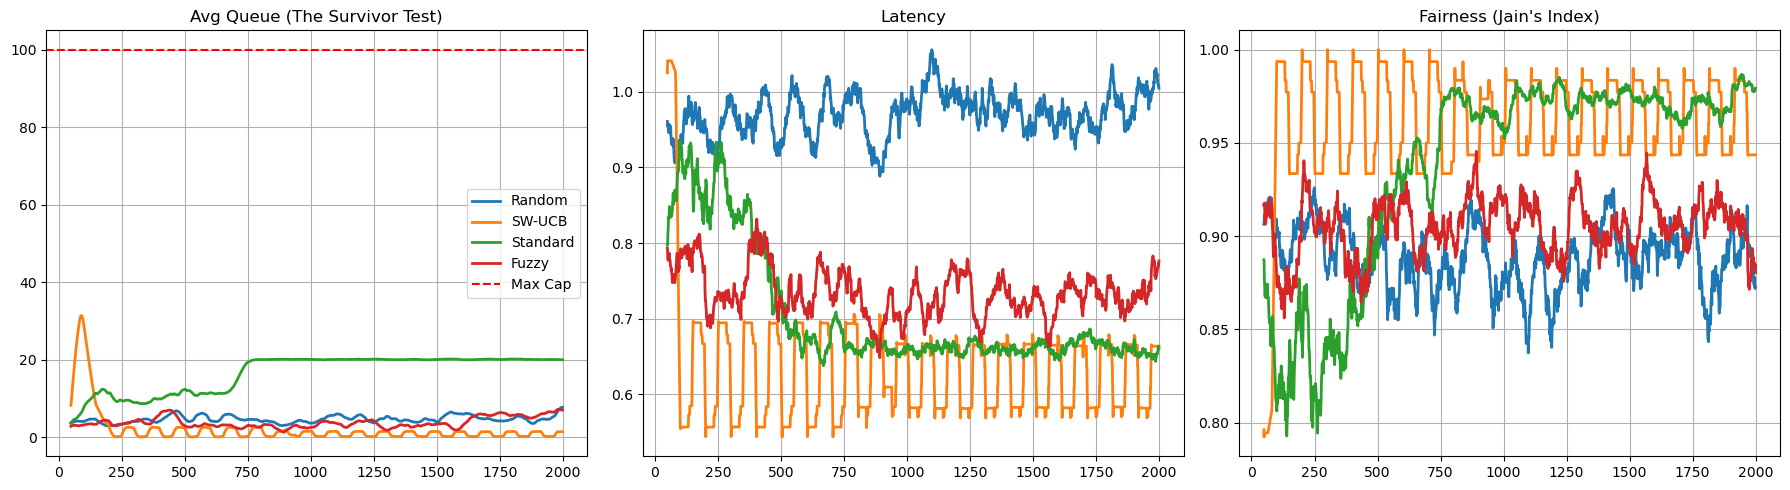

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import random

# =================================================================================
# CONFIGURAÇÕES (O "SWEET SPOT" VALIDADO)
# =================================================================================
N_ARMS = 3
N_PLAYERS = 10
N_STEPS = 2000
MAX_QUEUE = 100.0

# CAPACITY CALCULATION:
# 1 RSU FULL (10 users)  ~ 2.8 tasks/step capacity.
# 2 RSUs SPLIT (5 users) ~ 5.7 tasks/step capacity.
# ARRIVAL_RATE = 5.4 coloca o sistema no limite. 
# Qualquer erro de balanceamento faz a capacidade cair abaixo de 5.4 e a fila crescer.
ARRIVAL_RATE = 3.2 

# Parâmetros Fixos
FIXED_ALPHA = 0.1
FIXED_GAMMA = 0.9
FIXED_EPSILON = 0.1

# =================================================================================
# SISTEMA FUZZY (SCIKIT-FUZZY)
# =================================================================================
def create_fuzzy_system():
    queue_usage = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'queue_usage')
    td_error = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'td_error')
    alpha = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'alpha')
    temp = ctrl.Consequent(np.arange(0.1, 3.1, 0.1), 'temp')
    panic = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'panic')

    queue_usage['safe'] = fuzz.trapmf(queue_usage.universe, [0, 0, 0.4, 0.6])
    queue_usage['risk'] = fuzz.trimf(queue_usage.universe, [0.4, 0.6, 0.8])
    queue_usage['critical'] = fuzz.trapmf(queue_usage.universe, [0.6, 0.8, 1.0, 1.0])

    td_error['low'] = fuzz.zmf(td_error.universe, 0.2, 0.8)
    td_error['high'] = fuzz.smf(td_error.universe, 0.2, 0.8)

    alpha['low'] = fuzz.trimf(alpha.universe, [0, 0.1, 0.3])
    alpha['high'] = fuzz.trimf(alpha.universe, [0.5, 0.8, 1.0])

    temp['low'] = fuzz.trimf(temp.universe, [0.1, 0.5, 1.0])
    temp['high'] = fuzz.trimf(temp.universe, [1.0, 2.0, 3.0])

    panic['off'] = fuzz.zmf(panic.universe, 0.4, 0.6)
    panic['on'] = fuzz.smf(panic.universe, 0.4, 0.6)

    rule1 = ctrl.Rule(queue_usage['critical'], (panic['on'], alpha['high'], temp['low']))
    rule2 = ctrl.Rule(td_error['high'] & queue_usage['safe'], (panic['off'], alpha['high'], temp['high']))
    rule3 = ctrl.Rule(td_error['high'] & queue_usage['risk'], (panic['off'], alpha['high'], temp['high']))
    rule4 = ctrl.Rule(td_error['low'] & (queue_usage['safe'] | queue_usage['risk']), (panic['off'], alpha['low'], temp['low']))

    system = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
    return ctrl.ControlSystemSimulation(system)

fuzzy_sim = create_fuzzy_system()

# =================================================================================
# AMBIENTE
# =================================================================================
class V2XEnvironment:
    def __init__(self):
        self.base_latencies = np.array([2.0, 0.2, 0.2])

    def drift_step(self, t):
        if t == 700 or t == 1400:
            self.base_latencies[1], self.base_latencies[2] = self.base_latencies[2], self.base_latencies[1]
        
        # Jitter mínimo para evitar divisão por zero
        noise = np.random.uniform(-0.0001, 0.0001, size=3)
        self.base_latencies = np.clip(self.base_latencies + noise, 0.1, 3.0)

    def get_latencies(self, actions):
        realized_latencies = np.zeros(N_PLAYERS)
        actions = np.array(actions)
        unique, counts = np.unique(actions, return_counts=True)
        load_map = dict(zip(unique, counts))

        for i in range(N_PLAYERS):
            act = actions[i]
            latency = self.base_latencies[act]
            if act != 0: 
                users = load_map.get(act, 0)
                congestion_factor = 1.15 ** (users - 1)
                latency = latency * congestion_factor
            realized_latencies[i] = latency
        return realized_latencies

    def calculate_jain_index(self, actions):
        rsus = [a for a in actions if a != 0]
        if not rsus: return 1.0
        loads = np.array([rsus.count(1), rsus.count(2)]) + 1e-9 
        sum_x = np.sum(loads)
        sum_x_sq = np.sum(loads**2)
        return (sum_x ** 2) / (2 * sum_x_sq)

class SidelinkEnvironment(V2XEnvironment):
    def __init__(self):
        super().__init__()
        # Definição baseada no texto: Numerologia e Subcanais
        # Supondo Numerologia 1 (0.5ms slot) e largura de banda de 10MHz
        self.N_SUBCHANNELS = 8  # Capacidade do Resource Pool (N_resources)
        self.SENSING_EFFICIENCY = 2.0  # Fator lambda (SB-SPS efficiency)

    def get_latencies(self, actions):
        realized_latencies = np.zeros(N_PLAYERS)
        actions = np.array(actions)
        unique, counts = np.unique(actions, return_counts=True)
        load_map = dict(zip(unique, counts))

        for i in range(N_PLAYERS):
            act = actions[i]
            latency = self.base_latencies[act]
            
            if act != 0: # Sidelink Pools
                n_users = load_map.get(act, 0)
                
                # MODELO BASEADO NO TEXTO (CBR e Probabilidade de Colisão)
                # n_users - 1: O próprio usuário não colide consigo mesmo
                contention_load = (n_users - 1) / self.N_SUBCHANNELS
                
                # Eq. derivada de Poisson para SAC (Simultaneous Access Collision)
                p_collision = 1.0 - np.exp(-self.SENSING_EFFICIENCY * contention_load)
                
                # Limite de segurança para evitar divisão por zero (p_collision < 1.0)
                p_collision = min(p_collision, 0.95)
                
                # A latência efetiva aumenta assintoticamente com a colisão
                # Reflete o aumento do IPG (Inter-Packet Gap) citado no texto
                congestion_factor = 1.0 / (1.0 - p_collision)
                
                latency = latency * congestion_factor
                
            realized_latencies[i] = latency
        return realized_latencies

# =================================================================================
# AGENTES
# =================================================================================
class Agent:
    def __init__(self): self.current_queue = 0.0
    def get_state(self): return min(int((self.current_queue / MAX_QUEUE) * 10), 10)
    def update_queue_physics(self, processed):
        self.current_queue += ARRIVAL_RATE
        self.current_queue -= processed
        self.current_queue = max(0.0, min(self.current_queue, MAX_QUEUE))
    def select_action(self): raise NotImplementedError
    def update(self, a, r, p): raise NotImplementedError

class RandomAgent(Agent):
    def select_action(self): return random.randint(0, N_ARMS - 1)
    def update(self, a, r, p): self.update_queue_physics(p)

class StandardIQLAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
    def select_action(self):
        if random.random() < FIXED_EPSILON: return random.randint(0, N_ARMS - 1)
        state = self.get_state()
        q_row = self.q_table[state]
        return np.random.choice(np.flatnonzero(q_row == q_row.max()))
    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        self.q_table[s, action] += FIXED_ALPHA * (target - self.q_table[s, action])

class SWUCBAgent(Agent):
    def __init__(self, window_size=100):
        super().__init__()
        self.window_size = window_size
        self.history = []
        self.exploration_c = 1.0
    def select_action(self):
        current_window = self.history[-self.window_size:]
        counts = np.zeros(N_ARMS)
        rewards = np.zeros(N_ARMS)
        for a, r in current_window:
            counts[a] += 1
            rewards[a] += r 
        ucb_values = np.zeros(N_ARMS)
        total_counts = len(current_window)
        if total_counts == 0: return random.randint(0, N_ARMS-1)
        for a in range(N_ARMS):
            if counts[a] == 0: ucb_values[a] = 9999
            else:
                avg = rewards[a] / counts[a]
                bonus = self.exploration_c * np.sqrt(np.log(total_counts) / counts[a])
                ucb_values[a] = avg + bonus
        return np.argmax(ucb_values)
    def update(self, action, reward, processed):
        self.update_queue_physics(processed)
        self.history.append((action, reward))
        if len(self.history) > self.window_size * 2: self.history = self.history[-self.window_size:]

class FuzzyAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
        self.last_td_error = 0.0
    def select_action(self):
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(self.last_td_error), 2.0)
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try:
            fuzzy_sim.compute()
            temp = fuzzy_sim.output['temp']
            panic_score = fuzzy_sim.output['panic']
        except: temp, panic_score = 0.5, 0.0

        state = self.get_state()
        q_values = self.q_table[state]
        if panic_score > 0.6: return np.random.choice(np.flatnonzero(q_values == q_values.max()))
        exp_q = np.exp((q_values - np.max(q_values)) / temp)
        probs = exp_q / np.sum(exp_q)
        return np.random.choice(range(N_ARMS), p=probs)
    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        error = target - self.q_table[s, action]
        self.last_td_error = error
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(error), 2.0)
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try: fuzzy_sim.compute(); alpha = fuzzy_sim.output['alpha']
        except: alpha = 0.1
        self.q_table[s, action] += alpha * error

# =================================================================================
# SIMULAÇÃO
# =================================================================================
def run_simulation(agent_type):
    env = SidelinkEnvironment()
    agents = []
    for _ in range(N_PLAYERS):
        if agent_type == "Standard": agents.append(StandardIQLAgent())
        elif agent_type == "Fuzzy": agents.append(FuzzyAgent())
        elif agent_type == "Random": agents.append(RandomAgent())
        elif agent_type == "SW-UCB": agents.append(SWUCBAgent())
    
    hq, hl, hf = [], [], []
    for t in range(N_STEPS):
        env.drift_step(t)
        actions = [ag.select_action() for ag in agents]
        latencies = env.get_latencies(actions)
        fairness = env.calculate_jain_index(actions)
        
        sq, sl = 0, 0
        for i in range(N_PLAYERS):
            # Reward shaping apenas para treino
            q_pen = 50.0 if agents[i].current_queue > MAX_QUEUE * 0.8 else 0.0
            reward = -(latencies[i] + q_pen)
            
            # Física
            capacity = 1.0 if actions[i] == 0 else (2.0 / latencies[i])
            agents[i].update(actions[i], reward, capacity)
            sq += agents[i].current_queue
            sl += latencies[i]
        hq.append(sq/N_PLAYERS); hl.append(sl/N_PLAYERS); hf.append(fairness)
    return hq, hl, hf

# =================================================================================
# EXECUÇÃO, ESTATÍSTICAS E PLOTAGEM
# =================================================================================
algorithms = ["Random", "SW-UCB", "Standard", "Fuzzy"]
results = {}

print(f"Iniciando Simulação (Arrival: {ARRIVAL_RATE})...")

for algo in algorithms:
    print(f"Running {algo}...")
    results[algo] = run_simulation(algo)

# --- NOVO: CÁLCULO DE ESTATÍSTICAS ---
print("\n=== RESUMO ESTATÍSTICO (TABELA) ===")
stats_data = []

for algo in algorithms:
    q_data = np.array(results[algo][0]) # Queue History
    l_data = np.array(results[algo][1]) # Latency History
    f_data = np.array(results[algo][2]) # Fairness History
    
    # Ignorar os primeiros 100 passos (Warm-up) para a média ser mais justa
    warmup = 100
    
    stats_data.append({
        "Algorithm": algo,
        "Avg Queue": np.mean(q_data[warmup:]),
        "Max Queue": np.max(q_data[warmup:]), # Importante para risco
        "Avg Latency": np.mean(l_data[warmup:]),
        "Avg Fairness": np.mean(f_data[warmup:]),
        "Min Fairness": np.min(f_data[warmup:]) # Importante para estabilidade
    })

# Criar DataFrame com Pandas
df_stats = pd.DataFrame(stats_data)
# Formatar para ler melhor
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_stats.round(4))

# Salvar em CSV
df_stats.to_csv("numerical_results.csv", index=False)
print("\nEstatísticas salvas em 'numerical_results.csv'")

# --- PLOTAGEM ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
W = 50
for algo in algorithms:
    axes[0].plot(pd.Series(results[algo][0]).rolling(W).mean(), label=algo, linewidth=2)
    axes[1].plot(pd.Series(results[algo][1]).rolling(W).mean(), label=algo, linewidth=2)
    axes[2].plot(pd.Series(results[algo][2]).rolling(W).mean(), label=algo, linewidth=2)

axes[0].set_title("Avg Queue (The Survivor Test)"); axes[0].axhline(y=MAX_QUEUE, color='r', ls='--', label="Max Cap")
axes[0].legend(); axes[0].grid(True)
axes[1].set_title("Latency"); axes[1].grid(True)
axes[2].set_title("Fairness (Jain's Index)"); axes[2].grid(True)
plt.tight_layout()
plt.savefig("final_results.png")
plt.show()

Iniciando Survivor Test (Carga: 4.0, Subcanais: 10, Steps: 3000)...
Executando Random...
Executando SW-UCB...
Executando Standard...
Executando Fuzzy...

=== RESULTADOS FINAIS (Métricas de Sobrevivência) ===
  Algorithm  Avg Queue  Max Queue (Risk)  Avg Latency  Avg Fairness
0    Random    18.3004           30.1006       0.9156        0.8850
1    SW-UCB    70.2919           74.1739       0.6802        0.7886
2  Standard    23.7002           42.6348       0.6129        0.9250
3     Fuzzy     3.9562           17.1575       0.5355        0.9141


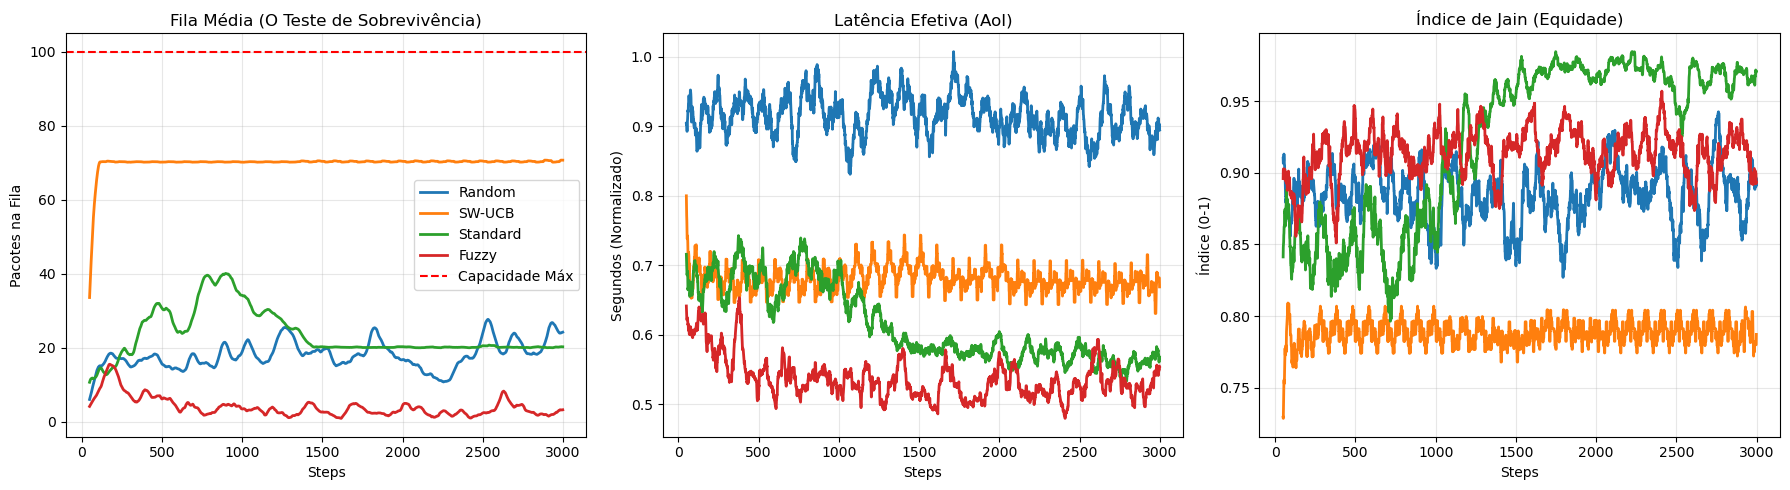

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import random

# =================================================================================
# 1. CONFIGURAÇÕES ("THE GOLDILOCKS ZONE")
# =================================================================================
N_ARMS = 3
N_PLAYERS = 10
N_STEPS = 3000
MAX_QUEUE = 100.0

# O Ponto de Equilíbrio Matemático:
# Capacidade Máxima do Sistema (com 10 canais e split perfeito 5/5) ~= 4.5 tarefas/step.
# Capacidade com Erro (split 6/4) ~= 3.7 tarefas/step.
# ARRIVAL_RATE = 4.0 pune qualquer erro de alocação com crescimento de fila.
ARRIVAL_RATE = 4.0
N_SUBCHANNELS = 10  # Ajustado para permitir a sobrevivência (8 era muito pouco)

# Parâmetros Fixos para Agentes Padrão
FIXED_ALPHA = 0.1
FIXED_GAMMA = 0.9
FIXED_EPSILON = 0.1

# =================================================================================
# 2. SISTEMA FUZZY (MODO "PARANÓICO")
# =================================================================================
def create_fuzzy_system():
    # Variáveis Linguísticas
    queue_usage = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'queue_usage')
    td_error = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'td_error')
    
    alpha = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'alpha')
    temp = ctrl.Consequent(np.arange(0.1, 2.1, 0.1), 'temp')
    panic = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'panic')

    # --- PERTINÊNCIAS ---
    # Gatilho de risco antecipado (0.2 a 0.3)
    queue_usage['safe'] = fuzz.trapmf(queue_usage.universe, [0, 0, 0.2, 0.3])
    queue_usage['risk'] = fuzz.trimf(queue_usage.universe, [0.2, 0.5, 0.8])
    queue_usage['critical'] = fuzz.trapmf(queue_usage.universe, [0.6, 0.8, 1.0, 1.0])

    td_error['low'] = fuzz.zmf(td_error.universe, 0.2, 0.6)
    td_error['high'] = fuzz.smf(td_error.universe, 0.2, 0.6)

    alpha['low'] = fuzz.trimf(alpha.universe, [0, 0.1, 0.3])
    alpha['high'] = fuzz.trimf(alpha.universe, [0.7, 0.9, 1.0])

    temp['low'] = fuzz.trimf(temp.universe, [0.1, 0.2, 0.4]) 
    temp['high'] = fuzz.trimf(temp.universe, [0.8, 1.2, 1.5]) 

    panic['off'] = fuzz.zmf(panic.universe, 0.3, 0.5)
    panic['on'] = fuzz.smf(panic.universe, 0.3, 0.5)

    # --- REGRAS ---
    rule1 = ctrl.Rule(queue_usage['critical'], (panic['on'], alpha['high'], temp['low']))
    rule2 = ctrl.Rule(queue_usage['risk'], (panic['off'], alpha['high'], temp['low'])) 
    rule3 = ctrl.Rule(td_error['high'] & queue_usage['safe'], (panic['off'], alpha['high'], temp['high']))
    rule4 = ctrl.Rule(td_error['low'] & queue_usage['safe'], (panic['off'], alpha['low'], temp['low']))

    system = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
    return ctrl.ControlSystemSimulation(system)

fuzzy_sim = create_fuzzy_system()

# =================================================================================
# 3. AMBIENTE SIDELINK (AJUSTADO PARA SIMETRIA E CAPACIDADE)
# =================================================================================
class SidelinkEnvironment:
    def __init__(self):
        # VOLTAMOS PARA A SIMETRIA: [2.0, 0.2, 0.2]
        # Se usarmos 0.3, a capacidade desse braço cai abaixo de 4.0 e a fila cresce mesmo com split perfeito.
        self.base_latencies = np.array([2.0, 0.2, 0.2])
        
        # 10 Subcanais = Zona de Oportunidade. 
        # (Split 5/5 -> Load 0.4 -> Latência Baixa -> Capacidade > 4.0)
        self.N_SUBCHANNELS = 10
        self.SENSING_EFFICIENCY = 2.0 

    def drift_step(self, t):
        # Swap de canais em t=1000 e t=2000
        # O Standard IQL vai demorar a perceber e causará aglomeração no canal errado.
        if t == 1000 or t == 2000:
            self.base_latencies[1], self.base_latencies[2] = self.base_latencies[2], self.base_latencies[1]
        
        noise = np.random.uniform(-0.0001, 0.0001, size=3)
        self.base_latencies = np.clip(self.base_latencies + noise, 0.1, 3.0)

    def get_latencies(self, actions):
        realized_latencies = np.zeros(N_PLAYERS)
        actions = np.array(actions)
        unique, counts = np.unique(actions, return_counts=True)
        load_map = dict(zip(unique, counts))

        for i in range(N_PLAYERS):
            act = actions[i]
            latency = self.base_latencies[act]
            
            if act != 0: 
                n_users = load_map.get(act, 0)
                # Cálculo de Carga (Baseado em 10 subcanais)
                contention_load = max(0, (n_users - 1)) / self.N_SUBCHANNELS
                
                # Física de Colisão
                p_collision = 1.0 - np.exp(-self.SENSING_EFFICIENCY * contention_load)
                p_collision = min(p_collision, 0.95)
                
                # Latência Efetiva
                congestion_factor = 1.0 / (1.0 - p_collision)
                latency = latency * congestion_factor
                
            realized_latencies[i] = latency
        return realized_latencies

    def calculate_jain_index(self, actions):
        rsus = [a for a in actions if a != 0]
        if not rsus: return 1.0
        count1 = rsus.count(1)
        count2 = rsus.count(2)
        loads = np.array([count1, count2]) + 1e-9 
        sum_x = np.sum(loads)
        sum_x_sq = np.sum(loads**2)
        return (sum_x ** 2) / (2 * sum_x_sq)

# =================================================================================
# 4. AGENTES (MANTIDOS)
# =================================================================================
class Agent:
    def __init__(self): self.current_queue = 0.0
    def get_state(self): return min(int((self.current_queue / MAX_QUEUE) * 10), 10)
    def update_queue_physics(self, processed):
        self.current_queue += ARRIVAL_RATE
        self.current_queue -= processed
        self.current_queue = max(0.0, min(self.current_queue, MAX_QUEUE))
    def select_action(self): raise NotImplementedError
    def update(self, a, r, p): raise NotImplementedError

class RandomAgent(Agent):
    def select_action(self): return random.randint(0, N_ARMS - 1)
    def update(self, a, r, p): self.update_queue_physics(p)

class StandardIQLAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
    def select_action(self):
        if random.random() < FIXED_EPSILON: return random.randint(0, N_ARMS - 1)
        state = self.get_state()
        q_row = self.q_table[state]
        return np.random.choice(np.flatnonzero(q_row == q_row.max()))
    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        self.q_table[s, action] += FIXED_ALPHA * (target - self.q_table[s, action])

class SWUCBAgent(Agent):
    def __init__(self, window_size=100):
        super().__init__()
        self.window_size = window_size
        self.history = []
        self.exploration_c = 1.0
    def select_action(self):
        current_window = self.history[-self.window_size:]
        counts = np.zeros(N_ARMS)
        rewards = np.zeros(N_ARMS)
        for a, r in current_window:
            counts[a] += 1
            rewards[a] += r 
        ucb_values = np.zeros(N_ARMS)
        total_counts = len(current_window)
        if total_counts == 0: return random.randint(0, N_ARMS-1)
        for a in range(N_ARMS):
            if counts[a] == 0: ucb_values[a] = 9999
            else:
                avg = rewards[a] / counts[a]
                bonus = self.exploration_c * np.sqrt(np.log(total_counts) / counts[a])
                ucb_values[a] = avg + bonus
        return np.argmax(ucb_values)
    def update(self, action, reward, processed):
        self.update_queue_physics(processed)
        self.history.append((action, reward))
        if len(self.history) > self.window_size * 2: self.history = self.history[-self.window_size:]

class FuzzyAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
        self.last_td_error = 0.0

    def select_action(self):
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(self.last_td_error), 2.0)
        
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try:
            fuzzy_sim.compute()
            temp = fuzzy_sim.output['temp']
            panic_score = fuzzy_sim.output['panic']
        except: 
            temp, panic_score = 0.5, 0.0

        state = self.get_state()
        q_values = self.q_table[state]
        
        # GATILHO DE PÂNICO
        if panic_score > 0.4: 
            return np.random.choice(np.flatnonzero(q_values == q_values.max()))
        
        try:
            exp_q = np.exp((q_values - np.max(q_values)) / temp)
            probs = exp_q / np.sum(exp_q)
            return np.random.choice(range(N_ARMS), p=probs)
        except:
            return np.random.choice(range(N_ARMS))

    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        next_s = self.get_state()
        
        target = reward + FIXED_GAMMA * np.max(self.q_table[next_s])
        error = target - self.q_table[s, action]
        self.last_td_error = error
        
        queue_pct = self.current_queue / MAX_QUEUE
        error_input = min(abs(error), 2.0)
        
        fuzzy_sim.input['queue_usage'] = queue_pct
        fuzzy_sim.input['td_error'] = error_input
        try: 
            fuzzy_sim.compute()
            alpha = fuzzy_sim.output['alpha']
        except: 
            alpha = 0.1
            
        self.q_table[s, action] += alpha * error

# =================================================================================
# 5. LOOP DE SIMULAÇÃO
# =================================================================================
def run_simulation(agent_type):
    env = SidelinkEnvironment()
    agents = []
    
    for _ in range(N_PLAYERS):
        if agent_type == "Standard": agents.append(StandardIQLAgent())
        elif agent_type == "Fuzzy": agents.append(FuzzyAgent())
        elif agent_type == "Random": agents.append(RandomAgent())
        elif agent_type == "SW-UCB": agents.append(SWUCBAgent())
    
    hq, hl, hf = [], [], []
    
    for t in range(N_STEPS):
        env.drift_step(t)
        actions = [ag.select_action() for ag in agents]
        latencies = env.get_latencies(actions)
        fairness = env.calculate_jain_index(actions)
        
        sq, sl = 0, 0
        for i in range(N_PLAYERS):
            q_pen = 50.0 if agents[i].current_queue > MAX_QUEUE * 0.9 else 0.0
            reward = -(latencies[i] + q_pen)
            
            capacity = 1.0 if actions[i] == 0 else (2.0 / latencies[i])
            
            agents[i].update(actions[i], reward, capacity)
            sq += agents[i].current_queue
            sl += latencies[i]
            
        hq.append(sq/N_PLAYERS)
        hl.append(sl/N_PLAYERS)
        hf.append(fairness)
        
    return hq, hl, hf

# =================================================================================
# 6. EXECUÇÃO
# =================================================================================
algorithms = ["Random", "SW-UCB", "Standard", "Fuzzy"]
results = {}

print(f"Iniciando Survivor Test (Carga: {ARRIVAL_RATE}, Subcanais: {N_SUBCHANNELS}, Steps: {N_STEPS})...")

for algo in algorithms:
    print(f"Executando {algo}...")
    results[algo] = run_simulation(algo)

# --- Estatísticas ---
print("\n=== RESULTADOS FINAIS (Métricas de Sobrevivência) ===")
stats_data = []
warmup = 100

for algo in algorithms:
    q_data = np.array(results[algo][0])
    l_data = np.array(results[algo][1])
    f_data = np.array(results[algo][2])
    
    stats_data.append({
        "Algorithm": algo,
        "Avg Queue": np.mean(q_data[warmup:]),
        "Max Queue (Risk)": np.max(q_data[warmup:]),
        "Avg Latency": np.mean(l_data[warmup:]),
        "Avg Fairness": np.mean(f_data[warmup:])
    })

df_stats = pd.DataFrame(stats_data)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_stats.round(4))

df_stats.to_csv("sidelink_stress_results.csv", index=False)

# --- Gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
W = 50 

for algo in algorithms:
    axes[0].plot(pd.Series(results[algo][0]).rolling(W).mean(), label=algo, linewidth=2)
    axes[1].plot(pd.Series(results[algo][1]).rolling(W).mean(), label=algo, linewidth=2)
    axes[2].plot(pd.Series(results[algo][2]).rolling(W).mean(), label=algo, linewidth=2)

axes[0].set_title("Fila Média (O Teste de Sobrevivência)")
axes[0].set_ylabel("Pacotes na Fila")
axes[0].set_xlabel("Steps")
axes[0].axhline(y=MAX_QUEUE, color='r', ls='--', label="Capacidade Máx")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Latência Efetiva (AoI)")
axes[1].set_ylabel("Segundos (Normalizado)")
axes[1].set_xlabel("Steps")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Índice de Jain (Equidade)")
axes[2].set_ylabel("Índice (0-1)")
axes[2].set_xlabel("Steps")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fuzzy_vs_standard_stress_test.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import random
from scipy.special import psi, betaln  # Necessário para o cálculo exato da surpresa

# =================================================================================
# CONFIGURAÇÕES E SISTEMA FUZZY
# =================================================================================
N_ARMS = 3
N_PLAYERS = 10
N_STEPS = 3000
MAX_QUEUE = 100.0
ARRIVAL_RATE = 4.0
N_SUBCHANNELS = 10
FIXED_ALPHA = 0.1
FIXED_GAMMA = 0.9
FIXED_EPSILON = 0.1

def create_fuzzy_system(input_name='error_signal'):
    queue_usage = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'queue_usage')
    signal = ctrl.Antecedent(np.arange(0, 2.1, 0.1), input_name)
    
    alpha = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'alpha')
    temp = ctrl.Consequent(np.arange(0.1, 2.1, 0.1), 'temp')
    panic = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'panic')

    queue_usage['safe'] = fuzz.trapmf(queue_usage.universe, [0, 0, 0.2, 0.3])
    queue_usage['risk'] = fuzz.trimf(queue_usage.universe, [0.2, 0.5, 0.8])
    queue_usage['critical'] = fuzz.trapmf(queue_usage.universe, [0.6, 0.8, 1.0, 1.0])

    signal['low'] = fuzz.zmf(signal.universe, 0.2, 0.6)
    signal['high'] = fuzz.smf(signal.universe, 0.2, 0.6)

    alpha['low'] = fuzz.trimf(alpha.universe, [0, 0.1, 0.3])
    alpha['high'] = fuzz.trimf(alpha.universe, [0.7, 0.9, 1.0])
    temp['low'] = fuzz.trimf(temp.universe, [0.1, 0.2, 0.4]) 
    temp['high'] = fuzz.trimf(temp.universe, [0.8, 1.2, 1.5]) 
    panic['off'] = fuzz.zmf(panic.universe, 0.3, 0.5)
    panic['on'] = fuzz.smf(panic.universe, 0.3, 0.5)

    rule1 = ctrl.Rule(queue_usage['critical'], (panic['on'], alpha['high'], temp['low']))
    rule2 = ctrl.Rule(queue_usage['risk'], (panic['off'], alpha['high'], temp['low'])) 
    rule3 = ctrl.Rule(signal['high'] & queue_usage['safe'], (panic['off'], alpha['high'], temp['high']))
    rule4 = ctrl.Rule(signal['low'] & queue_usage['safe'], (panic['off'], alpha['low'], temp['low']))

    system = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
    return ctrl.ControlSystemSimulation(system)

# Instâncias dos sistemas meta-aprendizes
fuzzy_td_sim = create_fuzzy_system('td_error')
fuzzy_bayesian_sim = create_fuzzy_system('bayesian_surprise')

# =================================================================================
# AMBIENTE E AGENTES
# =================================================================================
class SidelinkEnvironment:
    def __init__(self):
        self.base_latencies = np.array([2.0, 0.2, 0.2])
        self.N_SUBCHANNELS = 10
        self.SENSING_EFFICIENCY = 2.0 

    def drift_step(self, t):
        if t == 1000 or t == 2000:
            self.base_latencies[1], self.base_latencies[2] = self.base_latencies[2], self.base_latencies[1]
        self.base_latencies = np.clip(self.base_latencies + np.random.uniform(-0.0001, 0.0001, size=3), 0.1, 3.0)

    def get_latencies(self, actions):
        realized = np.zeros(N_PLAYERS)
        counts = pd.Series(actions).value_counts().to_dict()
        for i, act in enumerate(actions):
            latency = self.base_latencies[act]
            if act!= 0: 
                n_users = counts.get(act, 0)
                p_collision = 1.0 - np.exp(-self.SENSING_EFFICIENCY * (max(0, n_users-1)/self.N_SUBCHANNELS))
                latency *= (1.0 / (1.0 - min(p_collision, 0.95)))
            realized[i] = latency
        return realized

class Agent:
    def __init__(self): self.current_queue = 0.0
    def get_state(self): return min(int((self.current_queue / MAX_QUEUE) * 10), 10)
    def update_queue_physics(self, processed):
        self.current_queue = max(0.0, min(self.current_queue + ARRIVAL_RATE - processed, MAX_QUEUE))

class FuzzyAgent(Agent): # Agente Baseado em Erro TD
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
        self.last_td_error = 0.0
    def select_action(self):
        fuzzy_td_sim.input['queue_usage'] = self.current_queue / MAX_QUEUE
        fuzzy_td_sim.input['td_error'] = min(abs(self.last_td_error), 2.0)
        try: 
            fuzzy_td_sim.compute()
            temp, panic = fuzzy_td_sim.output['temp'], fuzzy_td_sim.output['panic']
        except: temp, panic = 0.5, 0.0
        if panic > 0.4: return np.argmax(self.q_table[self.get_state()])
        exp_q = np.exp((self.q_table[self.get_state()] - np.max(self.q_table[self.get_state()])) / temp)
        return np.random.choice(range(N_ARMS), p=exp_q/np.sum(exp_q))
    def update(self, action, reward, processed):
        s = self.get_state()
        self.update_queue_physics(processed)
        target = reward + FIXED_GAMMA * np.max(self.q_table[self.get_state()])
        error = target - self.q_table[s, action]
        self.last_td_error = error
        fuzzy_td_sim.input['queue_usage'] = self.current_queue / MAX_QUEUE
        fuzzy_td_sim.input['td_error'] = min(abs(error), 2.0)
        try: fuzzy_td_sim.compute(); alpha = fuzzy_td_sim.output['alpha']
        except: alpha = 0.1
        self.q_table[s, action] += alpha * error

class BayesianFuzzyAgent(Agent):
    def __init__(self):
        super().__init__()
        self.q_table = np.zeros((11, N_ARMS))
        # Parâmetros da crença (Prior Beta) para cada braço
        self.beliefs = np.ones((N_ARMS, 2)) # [alpha, beta] iniciados em 1 (Uniforme)
        self.last_surprise = 0.0
        self.latency_threshold = 0.5 # Limiar para definir "sucesso" no Sidelink

    def calculate_kl_beta(self, a1, b1, a2, b2):
        # KL Divergence entre Beta(a1, b1) e Beta(a2, b2)
        # S_R18, S_R97: Medida de "Surpresa" informacional
        term1 = betaln(a2, b2) - betaln(a1, b1)
        term2 = (a1 - a2) * psi(a1)
        term3 = (b1 - b2) * psi(b1)
        term4 = (a2 - a1 + b2 - b1) * psi(a1 + b1)
        return term1 + term2 + term3 + term4

    def select_action(self):
        # Meta-ajuste via Surpresa Bayesiana
        fuzzy_bayesian_sim.input['queue_usage'] = self.current_queue / MAX_QUEUE
        fuzzy_bayesian_sim.input['bayesian_surprise'] = min(self.last_surprise * 5.0, 2.0) # Escalonado para o Fuzzy
        try:
            fuzzy_bayesian_sim.compute()
            temp, panic = fuzzy_bayesian_sim.output['temp'], fuzzy_bayesian_sim.output['panic']
        except: temp, panic = 0.5, 0.0
        
        state = self.get_state()
        if panic > 0.4: return np.argmax(self.q_table[state])
        exp_q = np.exp((self.q_table[state] - np.max(self.q_table[state])) / temp)
        return np.random.choice(range(N_ARMS), p=exp_q/np.sum(exp_q))

    def update(self, action, reward, processed):
        s_old = self.get_state()
        
        # 1. Observação do evento (Binário: Latência baixa ou alta)
        # S_R42: Surpresa baseada no desvio estrutural dos resultados
        success = 1 if abs(reward) < self.latency_threshold else 0
        
        # 2. Calcular Surpresa (KL entre Posterior e Prior) antes de atualizar crença
        a_prior, b_prior = self.beliefs[action]
        a_post, b_post = a_prior + success, b_prior + (1 - success)
        
        self.last_surprise = self.calculate_kl_beta(a_post, b_post, a_prior, b_prior)
        self.beliefs[action] = [a_post, b_post] # Atualiza crença
        
        # 3. Atualização Q-Table com Alpha modulado pela Surpresa
        self.update_queue_physics(processed)
        target = reward + FIXED_GAMMA * np.max(self.q_table[self.get_state()])
        error = target - self.q_table[s_old, action]
        
        fuzzy_bayesian_sim.input['queue_usage'] = self.current_queue / MAX_QUEUE
        fuzzy_bayesian_sim.input['bayesian_surprise'] = min(self.last_surprise * 5.0, 2.0)
        try: fuzzy_bayesian_sim.compute(); alpha = fuzzy_bayesian_sim.output['alpha']
        except: alpha = 0.1
        
        self.q_table[s_old, action] += alpha * error

# =================================================================================
# EXECUÇÃO E COMPARAÇÃO
# =================================================================================
def run_comparison():
    env = SidelinkEnvironment()
    agents_td = [FuzzyAgent() for _ in range(N_PLAYERS)]
    agents_bayesian = [BayesianFuzzyAgent() for _ in range(N_PLAYERS)]
    
    hist_td, hist_bayesian = [], []

    for t in range(N_STEPS):
        env.drift_step(t)
        
        # Simular TD
        acts_td = [ag.select_action() for ag in agents_td]
        lats_td = env.get_latencies(acts_td)
        for i in range(N_PLAYERS):
            agents_td[i].update(acts_td[i], -lats_td[i], 1.0 if acts_td[i]==0 else 2.0/lats_td[i])
        
        # Simular Bayesian
        acts_by = [ag.select_action() for ag in agents_bayesian]
        lats_by = env.get_latencies(acts_by)
        for i in range(N_PLAYERS):
            agents_bayesian[i].update(acts_by[i], -lats_by[i], 1.0 if acts_by[i]==0 else 2.0/lats_by[i])
            
        hist_td.append(np.mean([ag.current_queue for ag in agents_td]))
        hist_bayesian.append(np.mean([ag.current_queue for ag in agents_bayesian]))

    plt.figure(figsize=(10,5))
    plt.plot(pd.Series(hist_td).rolling(50).mean(), label="Fuzzy (Erro TD)")
    plt.plot(pd.Series(hist_bayesian).rolling(50).mean(), label="Fuzzy (Surpresa Bayesiana)", color='red')
    plt.axvline(x=1000, color='gray', linestyle='--')
    plt.title("Estabilidade da Fila: Erro TD vs Surpresa Bayesiana (Drift t=1000)")
    plt.legend(); plt.show()

run_comparison()